In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [34]:
# Upload datasets
train_df = pd.read_csv('data/train_preprocessed.csv')
test_df = pd.read_csv('data/test_preprocessed.csv')
ID_COL = train_df["student_id"]

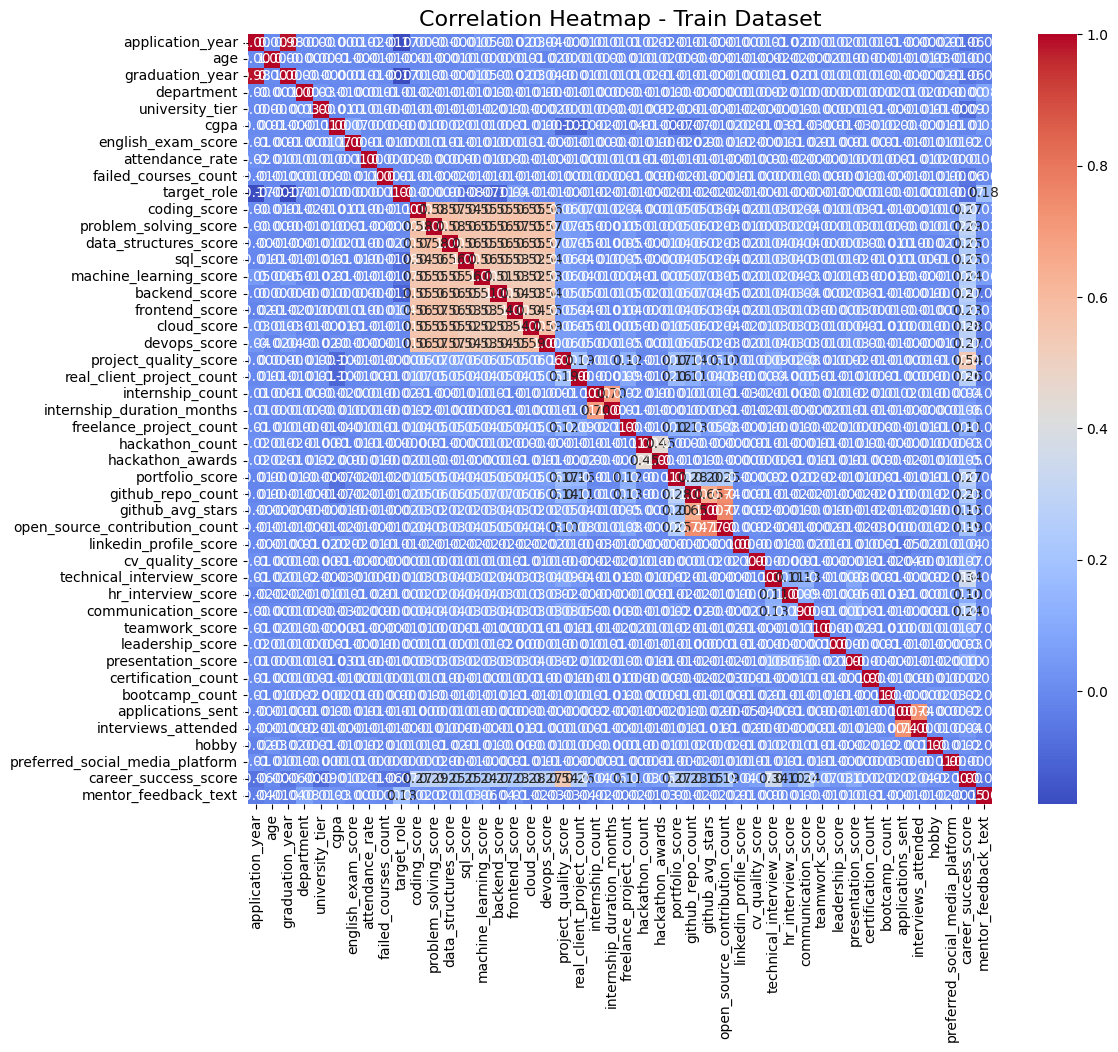

In [6]:
# Correlation heatmap / Train dataset
corr = train_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap - Train Dataset", fontsize=16)
plt.show()


Correlation with Career Success Score:
career_success_score               1.000000
project_quality_score              0.541063
technical_interview_score          0.340448
problem_solving_score              0.289990
cloud_score                        0.276863
coding_score                       0.274396
devops_score                       0.272033
backend_score                      0.266532
portfolio_score                    0.266340
real_client_project_count          0.258805
data_structures_score              0.251838
sql_score                          0.250567
machine_learning_score             0.242796
communication_score                0.237132
frontend_score                     0.232019
github_repo_count                  0.227029
open_source_contribution_count     0.190018
github_avg_stars                   0.148163
freelance_project_count            0.109153
hr_interview_score                 0.103238
presentation_score                 0.097600
teamwork_score                     0.

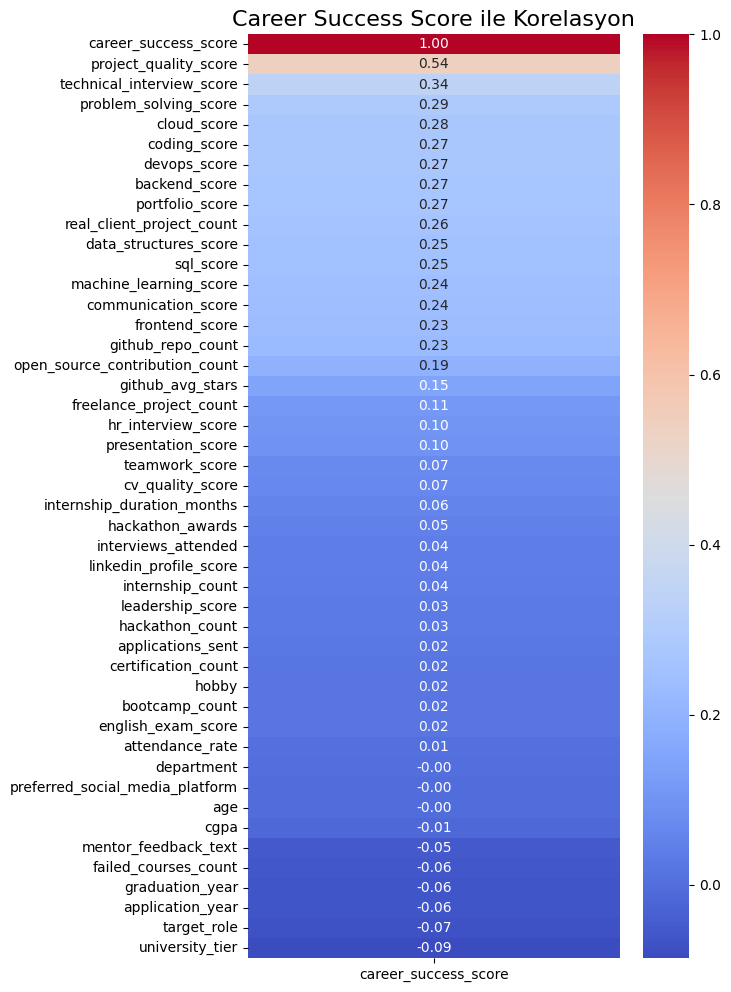

In [11]:
# Target correlation
target_corr = train_df.corr(numeric_only=True)["career_success_score"].sort_values(ascending=False)
print("Correlation with Career Success Score:")
print(target_corr)

# Heatmap çizimi
plt.figure(figsize=(6,12))
sns.heatmap(target_corr.to_frame(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Career Success Score ile Korelasyon", fontsize=16)
plt.show()

In [12]:
# Calcualting the software score
df = train_df.copy()


In [13]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Tarih/yaş ilişkili basit feature'lar
    df["years_since_graduation"] = df["application_year"] - df["graduation_year"]
    df["age_at_graduation"] = df["age"] - df["years_since_graduation"]
    df["is_recent_graduate"] = (df["years_since_graduation"] <= 1).astype(int)

    # Teknik skor özetleri
    technical_skill_cols = [
        "coding_score", "problem_solving_score", "data_structures_score",
        "sql_score", "machine_learning_score", "backend_score",
        "frontend_score", "cloud_score", "devops_score"
    ]

    df["technical_skill_mean"] = df[technical_skill_cols].mean(axis=1)
    df["technical_skill_std"] = df[technical_skill_cols].std(axis=1)
    df["technical_skill_min"] = df[technical_skill_cols].min(axis=1)
    df["technical_skill_max"] = df[technical_skill_cols].max(axis=1)
    df["technical_skill_range"] = df["technical_skill_max"] - df["technical_skill_min"]

    # Data/AI ve software odaklı teknik alt skorlar
    df["data_ai_score"] = df[
        [
            "sql_score",
            "machine_learning_score",
            "problem_solving_score",
            "data_structures_score",
            "coding_score"
        ]
    ].mean(axis=1)

    df["software_engineering_score"] = df[
        [
            "backend_score",
            "frontend_score",
            "cloud_score",
            "devops_score",
            "coding_score",
            "data_structures_score"
        ]
    ].mean(axis=1)

    # Soft skill özeti
    soft_skill_cols = [
        "communication_score",
        "teamwork_score",
        "leadership_score",
        "presentation_score",
        "linkedin_profile_score",
        "cv_quality_score",
        "hr_interview_score"
    ]

    df["soft_skill_mean"] = df[soft_skill_cols].mean(axis=1)
    df["soft_skill_std"] = df[soft_skill_cols].std(axis=1)

    # Deneyim/aktivite özeti
    experience_cols = [
        "real_client_project_count",
        "internship_count",
        "freelance_project_count",
        "hackathon_count",
        "certification_count",
        "bootcamp_count"
    ]

    df["experience_total"] = df[experience_cols].sum(axis=1)

    df["project_portfolio_score"] = (
        df["project_quality_score"]
        + df["portfolio_score"]
        + df["real_client_project_count"] * 5
        + df["freelance_project_count"] * 3
        + df["github_repo_count"] * 0.5
        + df["github_avg_stars"] * 0.5
        + df["open_source_contribution_count"] * 2
    )

    df["experience_score"] = (
        df["internship_count"] * 10
        + df["internship_duration_months"] * 2
        + df["freelance_project_count"] * 5
        + df["real_client_project_count"] * 7
    )

    df["competition_score"] = (
        df["hackathon_count"] * 3
        + df["hackathon_awards"] * 10
    )

    df["learning_activity_score"] = (
        df["certification_count"] * 2
        + df["bootcamp_count"] * 5
    )

    # Başvuru -> mülakat oranı
    df["interview_conversion_rate"] = (
        df["interviews_attended"] / (df["applications_sent"] + 1)
    )

    df["applications_without_interview"] = (
        df["applications_sent"] - df["interviews_attended"]
    )

    df["applications_per_year_after_grad"] = (
        df["applications_sent"] / (df["years_since_graduation"] + 1)
    )

    df["interview_per_year_after_grad"] = (
        df["interviews_attended"] / (df["years_since_graduation"] + 1)
    )

    df["interview_score_mean"] = df[
        ["technical_interview_score", "hr_interview_score"]
    ].mean(axis=1)

    df["weighted_interview_score"] = (
        df["technical_interview_score"] * 0.6
        + df["hr_interview_score"] * 0.4
    )

    df["interview_success_score"] = (
        df["interview_conversion_rate"] * df["weighted_interview_score"]
    )

    # Interaction feature'lar
    df["technical_x_project"] = (
        df["technical_skill_mean"] * df["project_portfolio_score"]
    )

    df["technical_x_experience"] = (
        df["technical_skill_mean"] * df["experience_score"]
    )

    df["soft_x_interview"] = (
        df["soft_skill_mean"] * df["weighted_interview_score"]
    )

    df["github_impact_score"] = (
        df["github_repo_count"]
        + df["github_avg_stars"] * 2
        + df["open_source_contribution_count"] * 3
    )

    df["internship_months_per_internship"] = (
        df["internship_duration_months"] / (df["internship_count"] + 1)
    )

    # Text'i modele direkt vermek yerine başlangıç için uzunluk feature'ları alıyoruz.
    # CatBoost text feature destekliyor ama localde daha yavaş çalışabilir.
    df["mentor_feedback_len"] = (
        df["mentor_feedback_text"]
        .fillna("")
        .astype(str)
        .str.len()
    )

    df["mentor_feedback_word_count"] = (
        df["mentor_feedback_text"]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

    # Sonsuz değer temizliği
    df = df.replace([np.inf, -np.inf], np.nan)

    return df


In [16]:
df_fe = add_features(df)

new_features = [
    "years_since_graduation",
    "age_at_graduation",
    "is_recent_graduate",
    "technical_skill_mean",
    "technical_skill_std",
    "technical_skill_min",
    "technical_skill_max",
    "technical_skill_range",
    "data_ai_score",
    "software_engineering_score",
    "soft_skill_mean",
    "soft_skill_std",
    "experience_total",
    "project_portfolio_score",
    "experience_score",
    "competition_score",
    "learning_activity_score",
    "interview_conversion_rate",
    "applications_without_interview",
    "applications_per_year_after_grad",
    "interview_per_year_after_grad",
    "interview_score_mean",
    "weighted_interview_score",
    "interview_success_score",
    "technical_x_project",
    "technical_x_experience",
    "soft_x_interview",
    "github_impact_score",
    "internship_months_per_internship",
    "mentor_feedback_len",
    "mentor_feedback_word_count"
]

df_final = df_fe[new_features + ["career_success_score"]]
print(df_final.head())

   years_since_graduation  age_at_graduation  is_recent_graduate  \
0                       0                 21                   1   
1                       0                 20                   1   
2                       0                 28                   1   
3                       1                 21                   1   
4                       0                 22                   1   

   technical_skill_mean  technical_skill_std  technical_skill_min  \
0             70.147169             9.815953             52.91000   
1             62.227270            11.118139             37.45074   
2             84.851461            10.685677             62.22000   
3             77.050698            12.974625             54.08000   
4             83.163333             7.417122             70.70000   

   technical_skill_max  technical_skill_range  data_ai_score  \
0                84.98               32.07000      72.810000   
1                78.90               41.44926   

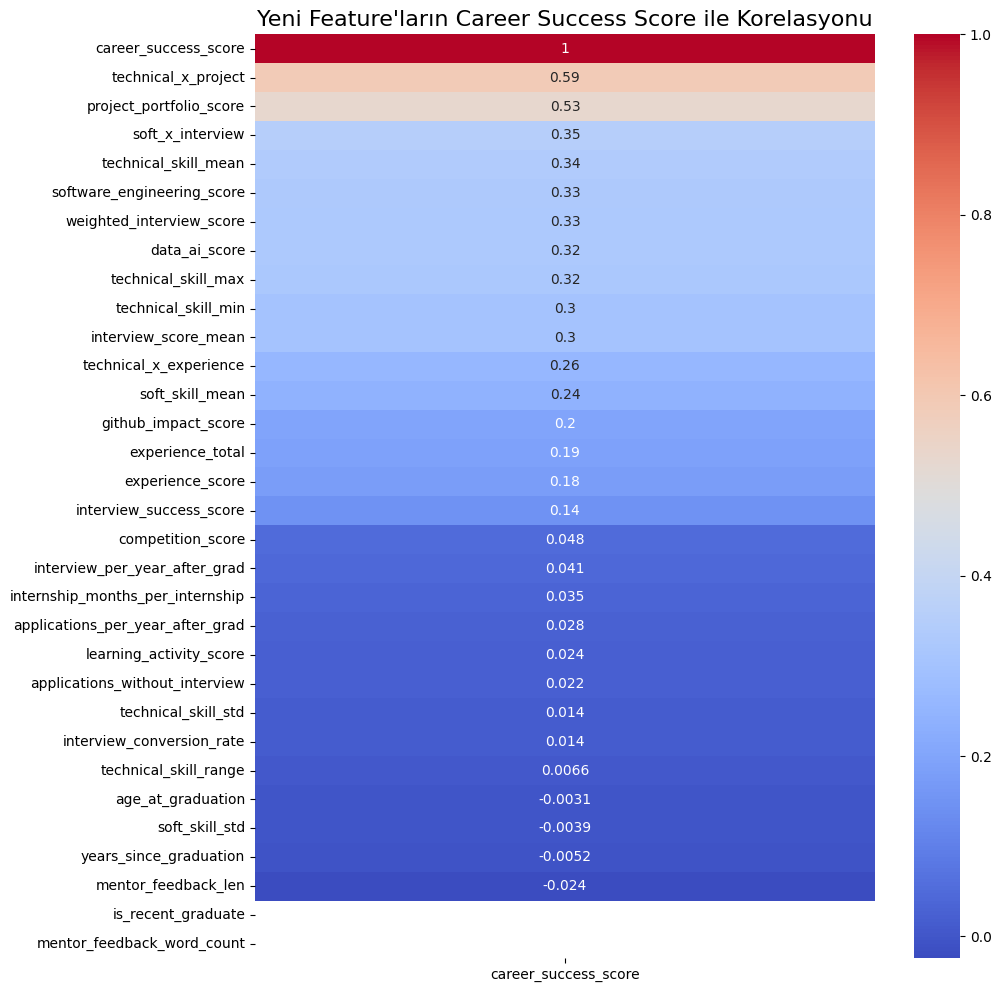

In [ ]:
# Target correlation with new features

# Korelasyon matrisi
corr = df_final.corr(numeric_only=True)

# Heatmap çizimi
plt.figure(figsize=(10,12))
sns.heatmap(corr[["career_success_score"]].sort_values(by="career_success_score", ascending=False),
            annot=True, cmap="coolwarm", cbar=True)
plt.title("Yeni Feature'ların Career Success Score ile Korelasyonu", fontsize=16)
plt.show()


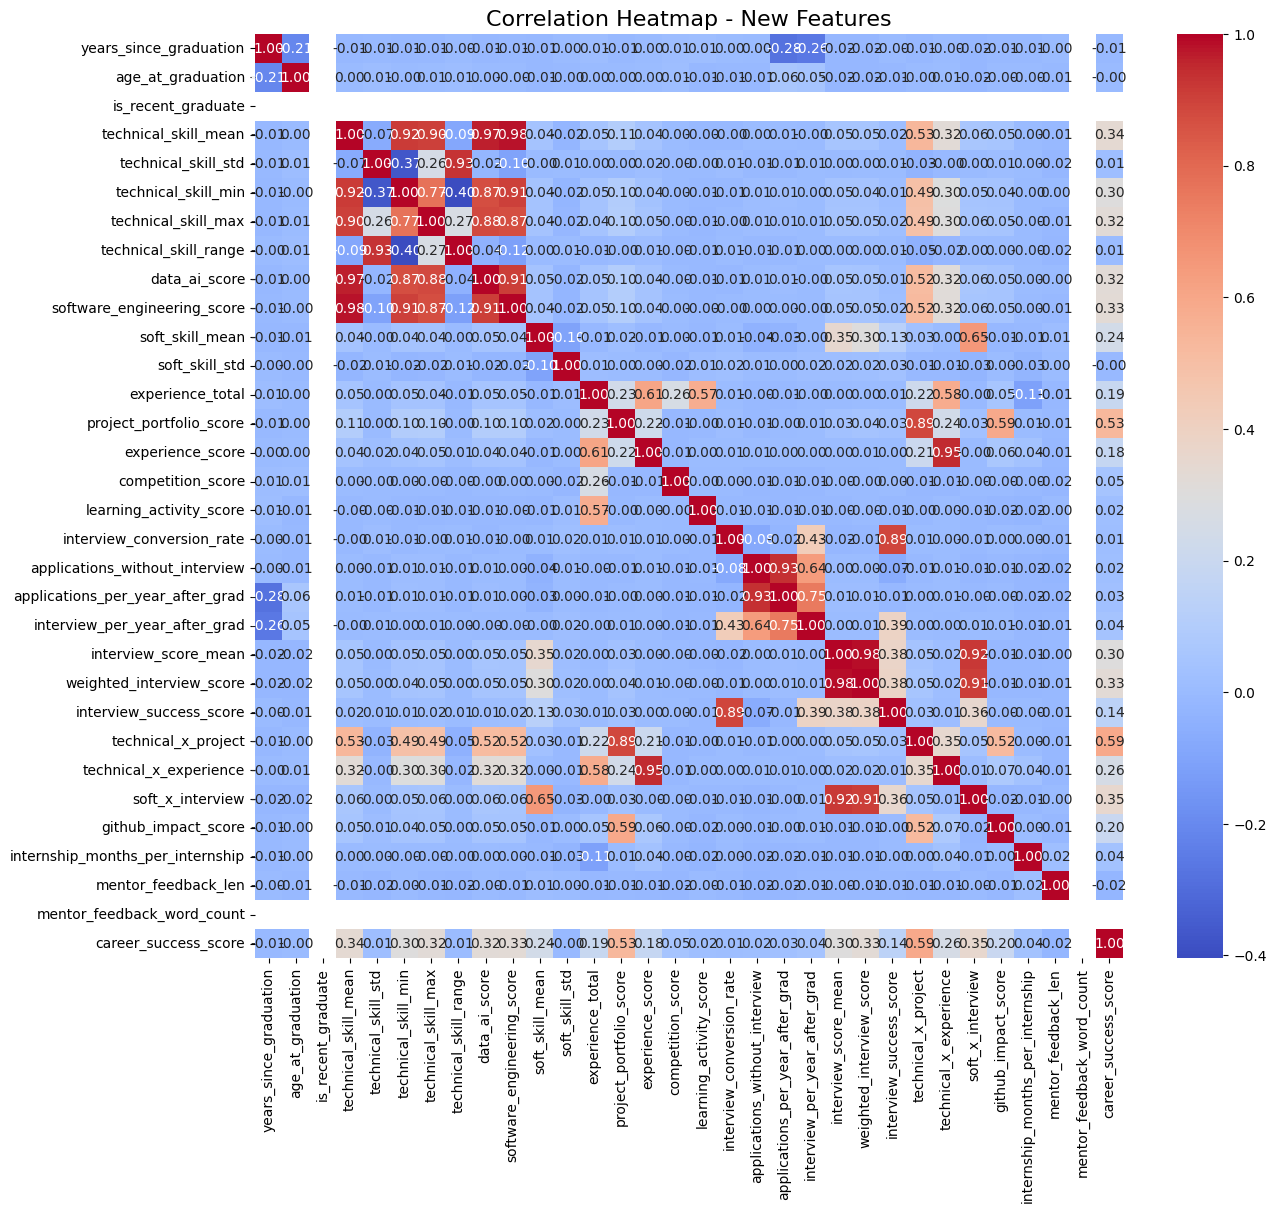

In [19]:
# Correlation in general
corr = df_final.corr(numeric_only=True)
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap - New Features", fontsize=16)
plt.show()

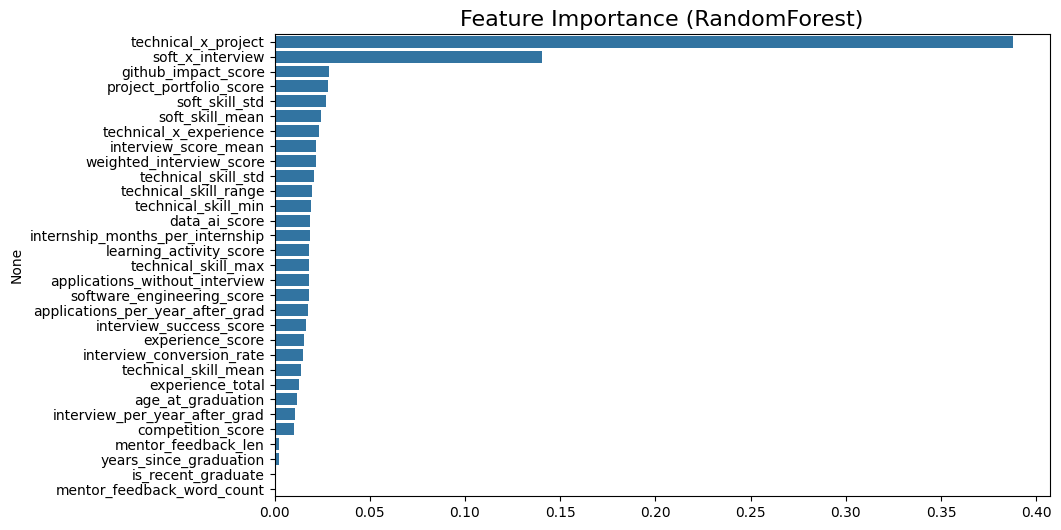

In [18]:
from sklearn.ensemble import RandomForestRegressor

X = df_final.drop("career_success_score", axis=1)
y = df_final["career_success_score"]

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance (RandomForest)", fontsize=16)
plt.show()


In [20]:
def feature_enginerring(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Academic Features
    df["academic_index"] = (
        df["cgpa"] * 0.5  +
        df["english_exam_score"] * 0.2 + 
        df["attendance_rate"] * 0.1 + 
        (5 - df["university_tier"]) * 0.1 # University quality (better if the tier is lower)
        - df["failed_courses_count"] * 0.1 # Penalize failed courses
    )

    # Technical Skills
    technical_cols = [
        "coding_score", "problem_solving_score", "data_structures_score",
        "sql_score", "machine_learning_score", "backend_score",
        "frontend_score", "cloud_score", "devops_score"
    ]
    df["technical_skill_avg"] = df[technical_cols].mean(axis=1)
    df["technical_skill_balance"] = df[technical_cols].std(axis=1) # More balanced skills might be better

    # Soft Skills
    soft_cols = ["communication_score", "teamwork_score", "leadership_score", "presentation_score"]
    df["soft_skill_index"] = df[soft_cols].mean(axis=1) # Average soft skill score

    # Experience
    df["internship_quality_score"] = (
        df["internship_duration_months"] * 0.7 +
        df["internship_count"] * 0.3
    )
    df["hackathon_success_rate"] = df["hackathon_awards"] / (df["hackathon_count"] + 1)

    df["experience_index"] = (
        df["internship_quality_score"] * 0.5 +
        df["real_client_project_count"] * 0.3 +
        df["freelance_project_count"] * 0.2 +
        df["hackathon_success_rate"] * 0.1
    )

    # Visibility / Portfolio
    df["github_impact_score"] = (
        df["github_repo_count"] * 0.5 +
        df["github_avg_stars"] * 0.2 +
        df["open_source_contribution_count"] * 0.3
    )

    df["visibility_index"] = (
        df["linkedin_profile_score"] * 0.4 +
        df["portfolio_score"] * 0.3 +
        df["github_impact_score"] * 0.3
    )

    # Interview Performance
    df["application_success_rate"] = df["interviews_attended"] / (df["applications_sent"] + 1)
    df["interview_score_index"] = (
        df["technical_interview_score"] * 0.6 +
        df["hr_interview_score"] * 0.4
    ) 

    return df


In [21]:
df_feature_engineered = feature_enginerring(df)


# Yeni feature kolonlarını seç
new_features = [
    "academic_index", "technical_skill_avg", "technical_skill_balance",
    "soft_skill_index", "internship_quality_score", "hackathon_success_rate",
    "experience_index", "github_impact_score", "visibility_index",
    "application_success_rate", "interview_score_index"
]

# Sadece yeni feature’lar + hedef değişkeni tut
df_final = df_feature_engineered[new_features + ["career_success_score"]]


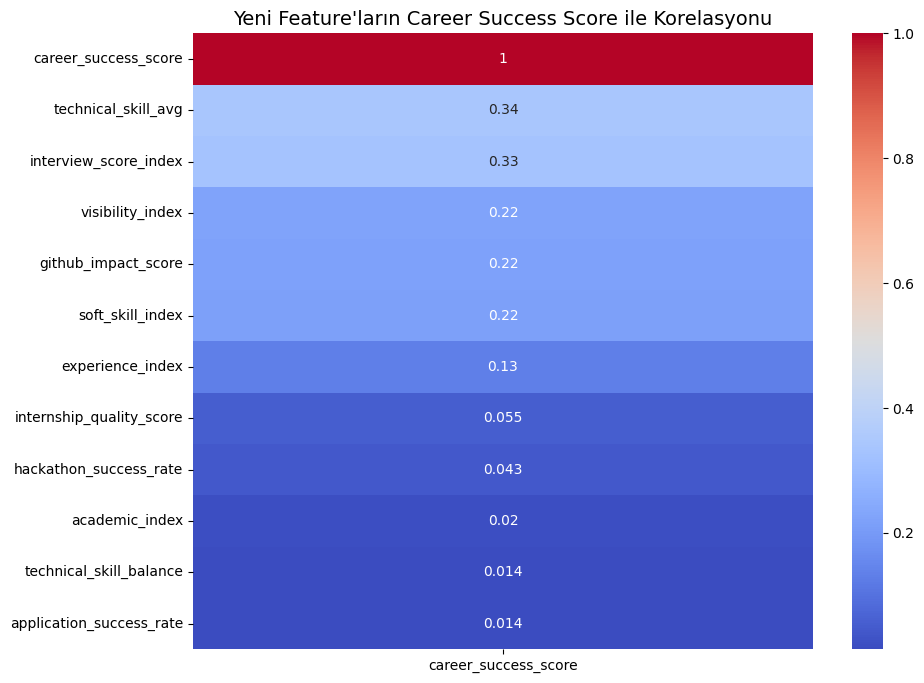

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_final.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr[["career_success_score"]].sort_values(by="career_success_score", ascending=False),
            annot=True, cmap="coolwarm", cbar=True)
plt.title("Yeni Feature'ların Career Success Score ile Korelasyonu", fontsize=14)
plt.show()


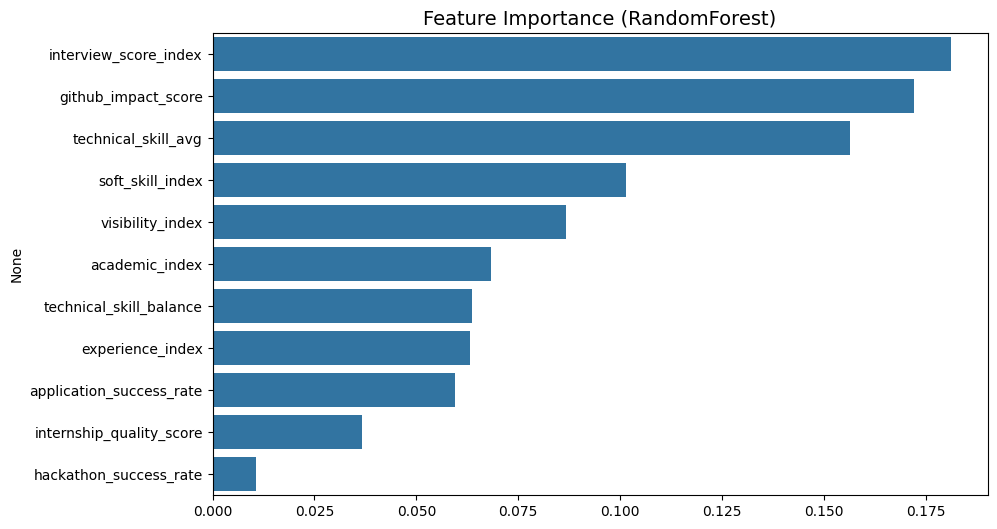

In [23]:
from sklearn.ensemble import RandomForestRegressor

X = df_final.drop("career_success_score", axis=1)
y = df_final["career_success_score"]

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance (RandomForest)", fontsize=14)
plt.show()


In [24]:
from sklearn.linear_model import LassoCV
import pandas as pd

X = df_final.drop("career_success_score", axis=1)
y = df_final["career_success_score"]

# LassoCV otomatik olarak en iyi alpha'yı seçer
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X, y)

# Katsayıları incele
lasso_coef = pd.Series(lasso.coef_, index=X.columns)

print("Lasso Katsayıları:")
print(lasso_coef.sort_values(ascending=False))


Lasso Katsayıları:
experience_index            6.421819
hackathon_success_rate      1.270913
github_impact_score         0.416017
technical_skill_avg         0.401622
interview_score_index       0.306383
soft_skill_index            0.264954
visibility_index            0.228667
technical_skill_balance     0.197469
academic_index              0.110113
application_success_rate    0.000000
internship_quality_score   -2.892963
dtype: float64


In [25]:
test_feature_engineered = feature_enginerring(test_df)
X = df_final.drop("career_success_score", axis=1)
y = df_final["career_success_score"]

X_test = test_feature_engineered[X.columns]

# catboost training without gridsearch and feature selection

In [41]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from math import sqrt

ID_COL = "student_id"
RANDOM_STATE = 42
TARGET = "career_success_score"

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# CatBoost parametreleri
cat_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 1500,
    "learning_rate": 0.03,
    "depth": 6,
    "l2_leaf_reg": 5,
    "random_seed": RANDOM_STATE,
    "od_type": "Iter",
    "od_wait": 100,
    "verbose": 200,
    "allow_writing_files": False
}

# KFold CV
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), start=1):
    print(f"========== Fold {fold} ==========")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = CatBoostRegressor(**cat_params)
    model.fit(
        X_train, y_train,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    valid_pred = model.predict(X_valid)
    oof_preds[valid_idx] = valid_pred

    fold_rmse = mean_squared_error(y_valid, valid_pred)
    fold_rmse = sqrt(fold_rmse)
    fold_scores.append(fold_rmse)
    print(f"Fold {fold} RMSE: {fold_rmse:.5f}")

    test_preds += model.predict(X_test) / kf.n_splits

# OOF RMSE
oof_rmse = mean_squared_error(y, oof_preds)
oof_rmse = sqrt(oof_rmse)
print("========== CV RESULT ==========")
print(f"Fold RMSE values: {[round(s, 5) for s in fold_scores]}")
print(f"Mean RMSE: {np.mean(fold_scores):.5f}")
print(f"Std RMSE : {np.std(fold_scores):.5f}")
print(f"OOF RMSE : {oof_rmse:.5f}")

# Tahminleri 0-100 aralığına sıkıştır
test_preds_clipped = np.clip(test_preds, 0, 100)

submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET: test_preds_clipped
})

submission.to_csv("catboost_submission.csv", index=False)
print("Saved: catboost_submission.csv")

========== Fold 1 ==========
0:	learn: 15.0797037	test: 15.0675597	best: 15.0675597 (0)	total: 3.33ms	remaining: 4.99s
200:	learn: 11.7334787	test: 12.2895757	best: 12.2892909 (198)	total: 446ms	remaining: 2.88s
400:	learn: 11.3106821	test: 12.2119676	best: 12.2118390 (399)	total: 875ms	remaining: 2.4s
600:	learn: 10.9291832	test: 12.1886625	best: 12.1886625 (600)	total: 1.3s	remaining: 1.95s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 12.18116723
bestIteration = 650

Shrink model to first 651 iterations.
Fold 1 RMSE: 12.18117
========== Fold 2 ==========
0:	learn: 15.0262960	test: 15.2751123	best: 15.2751123 (0)	total: 3.01ms	remaining: 4.51s
200:	learn: 11.7171548	test: 12.3299867	best: 12.3297840 (199)	total: 472ms	remaining: 3.05s
400:	learn: 11.2973238	test: 12.2762937	best: 12.2717830 (365)	total: 931ms	remaining: 2.55s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 12.27178299
bestIteration = 365

Shrink model to first 366 iterations.
F

# 📌 GridSearch ile CatBoost Parametre Optimizasyonu

In [42]:
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from math import sqrt

ID_COL = "student_id"
RANDOM_STATE = 42
TARGET = "career_success_score"

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# CatBoost model (base)
cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False
)

# GridSearch parametreleri
param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05],
    "l2_leaf_reg": [3, 5, 7],
    "iterations": [500, 1000, 1500]
}

# RMSE scorer
rmse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# KFold CV
kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# GridSearch
grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    scoring=rmse_scorer,
    cv=kf,
    n_jobs=-1
)

grid_search.fit(X_scaled, y)

print("Best Parameters:", grid_search.best_params_)
print("Best RMSE (MSE value, take sqrt):", sqrt(-grid_search.best_score_))


Best Parameters: {'depth': 4, 'iterations': 500, 'l2_leaf_reg': 7, 'learning_rate': 0.05}
Best RMSE (MSE value, take sqrt): 12.120023712914174


# 📌 CatBoost trainig with feature selection scope of the lasso 

In [43]:
df_final.head()

,academic_index,technical_skill_avg,technical_skill_balance,soft_skill_index,internship_quality_score,hackathon_success_rate,experience_index,github_impact_score,visibility_index,application_success_rate,interview_score_index,career_success_score
0,22.024,70.147169,9.815953,61.3775,8.6,0.0,4.3,12.370,58.0050,0.000000,44.458,86.78
1,25.253,62.227270,11.118139,37.1275,2.8,0.0,1.6,4.044,30.8932,0.106383,76.766,46.16
2,24.870,84.851461,10.685677,61.0225,0.0,0.0,1.0,5.024,48.5852,0.106383,33.912,84.08
3,20.460,77.050698,12.974625,56.8675,6.6,0.0,3.3,3.492,43.8276,0.140000,30.436,89.97
4,22.987,83.163333,7.417122,56.9175,2.8,0.0,2.4,10.794,47.5882,0.108333,69.148,92.46


In [51]:
X_test.head()

,academic_index,technical_skill_avg,technical_skill_balance,soft_skill_index,internship_quality_score,hackathon_success_rate,experience_index,github_impact_score,visibility_index,application_success_rate,interview_score_index
0,18.260,48.304840,10.528693,63.2425,10.4,0.0,5.70,5.406,35.427800,0.127660,54.456
1,22.078,76.922052,10.318142,61.5475,3.8,0.0,2.40,4.228,30.808400,0.000000,59.278
2,23.923,68.008291,10.468909,67.3975,1.7,0.0,1.75,5.406,25.341800,0.044776,69.028
3,19.371,72.437910,12.179686,74.1125,0.0,0.0,0.30,6.036,45.170289,0.046512,82.520
4,22.659,64.396667,11.090201,43.4550,4.5,0.0,3.05,5.208,48.624400,0.000000,50.956


Feature Selection process

In [45]:
def select_features_by_coeff(df: pd.DataFrame, coefficients: dict, threshold: float = 0.1) -> pd.DataFrame:
    """
    Lasso katsayılarına göre feature seçimi yapar.
   Args:
        df (pd.DataFrame): Feature engineering sonrası DataFrame
        coefficients (dict): Feature isimleri ve katsayıları {feature: coef}
        threshold (float): Minimum katsayı değeri (varsayılan 0.0 → negatif ve sıfırları çıkarır)
    
    Returns:
        pd.DataFrame: Seçilmiş feature seti
    """
    # Katsayıları DataFrame'e çevir
    coef_df = pd.DataFrame.from_dict(coefficients, orient="index", columns=["coef"])
    
    # Threshold üstündeki feature’ları seç
    selected_features = coef_df[coef_df["coef"] > threshold].index.tolist()
    
    print("Seçilen Feature'lar:", selected_features)
    
    return df[selected_features]

In [53]:
# Lasso 
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import pandas as pd

ID_COL = "student_id"
TARGET = "career_success_score"

X = df_final.drop("career_success_score", axis=1)
y = df_final["career_success_score"]

#Scale features for Lasso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate Lasso coefficients
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, y)

lasso_coef = dict(zip(X.columns, lasso.coef_))
print("Lasso Coefficients:", lasso_coef)

# Feature selection based on Lasso coefficients
X_selected = select_features_by_coeff(df_final.drop(columns=[TARGET]), lasso_coef, threshold=0.0)
X_test_selected = select_features_by_coeff(X_test, lasso_coef, threshold=0.0)

y = df_final[TARGET]

Lasso Coefficients: {'academic_index': 0.4316010898759681, 'technical_skill_avg': 4.357596959751563, 'technical_skill_balance': 0.4926439160511417, 'soft_skill_index': 2.579231045009256, 'internship_quality_score': -8.942989171668977, 'hackathon_success_rate': 0.6343345988627876, 'experience_index': 10.261613751963527, 'github_impact_score': 2.0830656441480775, 'visibility_index': 2.2190046744737733, 'application_success_rate': 0.18735588393587652, 'interview_score_index': 4.4003319980575775}
Seçilen Feature'lar: ['academic_index', 'technical_skill_avg', 'technical_skill_balance', 'soft_skill_index', 'hackathon_success_rate', 'experience_index', 'github_impact_score', 'visibility_index', 'application_success_rate', 'interview_score_index']
Seçilen Feature'lar: ['academic_index', 'technical_skill_avg', 'technical_skill_balance', 'soft_skill_index', 'hackathon_success_rate', 'experience_index', 'github_impact_score', 'visibility_index', 'application_success_rate', 'interview_score_index'

In [55]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
from math import sqrt

RANDOM_STATE = 42
TARGET = "career_success_score"

# Train ve test setleri (feature selection sonrası)
X_selected = select_features_by_coeff(df_final.drop(columns=[TARGET]), lasso_coef, threshold=0.0)
X_test_selected = select_features_by_coeff(X_test, lasso_coef, threshold=0.0)
y = df_final[TARGET]

# CatBoost parametreleri
cat_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 1500,
    "learning_rate": 0.03,
    "depth": 6,
    "l2_leaf_reg": 5,
    "random_seed": RANDOM_STATE,
    "od_type": "Iter",
    "od_wait": 100,
    "verbose": 200,
    "allow_writing_files": False
}

# KFold CV
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(X_selected))
test_preds = np.zeros(len(X_test_selected))
fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X_selected, y), start=1):
    print(f"========== Fold {fold} ==========")

    X_train, X_valid = X_selected.iloc[train_idx], X_selected.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = CatBoostRegressor(**cat_params)
    model.fit(
        X_train, y_train,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    valid_pred = model.predict(X_valid)
    oof_preds[valid_idx] = valid_pred

    fold_rmse = sqrt(mean_squared_error(y_valid, valid_pred))
    fold_scores.append(fold_rmse)
    print(f"Fold {fold} RMSE: {fold_rmse:.5f}")

    test_preds += model.predict(X_test_selected) / kf.n_splits

# OOF RMSE
oof_rmse = sqrt(mean_squared_error(y, oof_preds))
print("========== CV RESULT ==========")
print(f"Fold RMSE values: {[round(s, 5) for s in fold_scores]}")
print(f"Mean RMSE: {np.mean(fold_scores):.5f}")
print(f"Std RMSE : {np.std(fold_scores):.5f}")
print(f"OOF RMSE : {oof_rmse:.5f}")

# Tahminleri 0-100 aralığına sıkıştır
test_preds_clipped = np.clip(test_preds, 0, 100)

submission = pd.DataFrame({
    "student_id": test_df["student_id"],  # test_df’de ID varsa buradan al
    TARGET: test_preds_clipped
})

submission.to_csv("catboost_submission_selected.csv", index=False)
print("Saved: catboost_submission_selected.csv")


Seçilen Feature'lar: ['academic_index', 'technical_skill_avg', 'technical_skill_balance', 'soft_skill_index', 'hackathon_success_rate', 'experience_index', 'github_impact_score', 'visibility_index', 'application_success_rate', 'interview_score_index']
Seçilen Feature'lar: ['academic_index', 'technical_skill_avg', 'technical_skill_balance', 'soft_skill_index', 'hackathon_success_rate', 'experience_index', 'github_impact_score', 'visibility_index', 'application_success_rate', 'interview_score_index']
========== Fold 1 ==========
0:	learn: 15.0724577	test: 15.0576254	best: 15.0576254 (0)	total: 2.65ms	remaining: 3.98s
200:	learn: 11.7505890	test: 12.3010394	best: 12.3010394 (200)	total: 452ms	remaining: 2.92s
400:	learn: 11.3917217	test: 12.2603432	best: 12.2592096 (350)	total: 884ms	remaining: 2.42s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 12.25892932
bestIteration = 405

Shrink model to first 406 iterations.
Fold 1 RMSE: 12.25893
========== Fold 2 ==========
0: